In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

from wordcloud import WordCloud

In [109]:
df=pd.read_csv("amazon_prime_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [110]:
df.shape

(9668, 12)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  listed_in     9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB


In [112]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [113]:
df.rename(columns={"listed_in":"genre"},inplace=True)
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')

In [114]:
df.drop(columns='show_id',inplace=True)
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description'],
      dtype='object')

In [115]:
df.isnull().sum()

type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
genre              0
description        0
dtype: int64

In [116]:
df.drop(columns='description',inplace=True)
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre'],
      dtype='object')

In [117]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama"
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy"


In [118]:
df.duplicated().sum()

np.int64(0)

In [119]:
df.type.value_counts()

type
Movie      7814
TV Show    1854
Name: count, dtype: int64

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          9668 non-null   object
 1   title         9668 non-null   object
 2   director      7585 non-null   object
 3   cast          8435 non-null   object
 4   country       672 non-null    object
 5   date_added    155 non-null    object
 6   release_year  9668 non-null   int64 
 7   rating        9331 non-null   object
 8   duration      9668 non-null   object
 9   genre         9668 non-null   object
dtypes: int64(1), object(9)
memory usage: 755.4+ KB


In [121]:
df.isnull().sum()

type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
genre              0
dtype: int64

In [122]:
# filling the null values
df.director.fillna('Unavailable',inplace=True)
df.cast.fillna('Unavailable',inplace=True)
df.country.fillna('Unavailable',inplace=True)
df.date_added=df.date_added.ffill()
df.rating=df.rating.fillna(df.rating.mode()[0])

In [123]:
df.isnull().sum()

type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genre           0
dtype: int64

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          9668 non-null   object
 1   title         9668 non-null   object
 2   director      9668 non-null   object
 3   cast          9668 non-null   object
 4   country       9668 non-null   object
 5   date_added    9668 non-null   object
 6   release_year  9668 non-null   int64 
 7   rating        9668 non-null   object
 8   duration      9668 non-null   object
 9   genre         9668 non-null   object
dtypes: int64(1), object(9)
memory usage: 755.4+ KB


In [125]:
df.date_added=pd.to_datetime(df.date_added)


In [126]:
df['day']=df.date_added.dt.day
df['month']=df.date_added.dt.month
df['year']=df.date_added.dt.year
df['month_name']=df.date_added.dt.month_name()
df['weekday']=df.date_added.dt.day_name()
df.head()


,type,title,director,cast,country,date_added,release_year,rating,duration,genre,day,month,year,month_name,weekday
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama",30,3,2021,March,Tuesday
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International",30,3,2021,March,Tuesday
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense",30,3,2021,March,Tuesday
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary,30,3,2021,March,Tuesday
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,13+,45 min,"Drama, Fantasy",30,3,2021,March,Tuesday


In [127]:
filtered_directors=df[df.director!='Unavailable']
top_directors=filtered_directors.director.value_counts()[:10]

In [128]:
top_directors

director
Mark Knight              113
Cannis Holder             61
Moonbug Entertainment     37
Jay Chapman               34
Arthur van Merwijk        30
Manny Rodriguez           22
John English              20
1                         16
Brian Volk-Weiss          15
Baeble Music              14
Name: count, dtype: int64

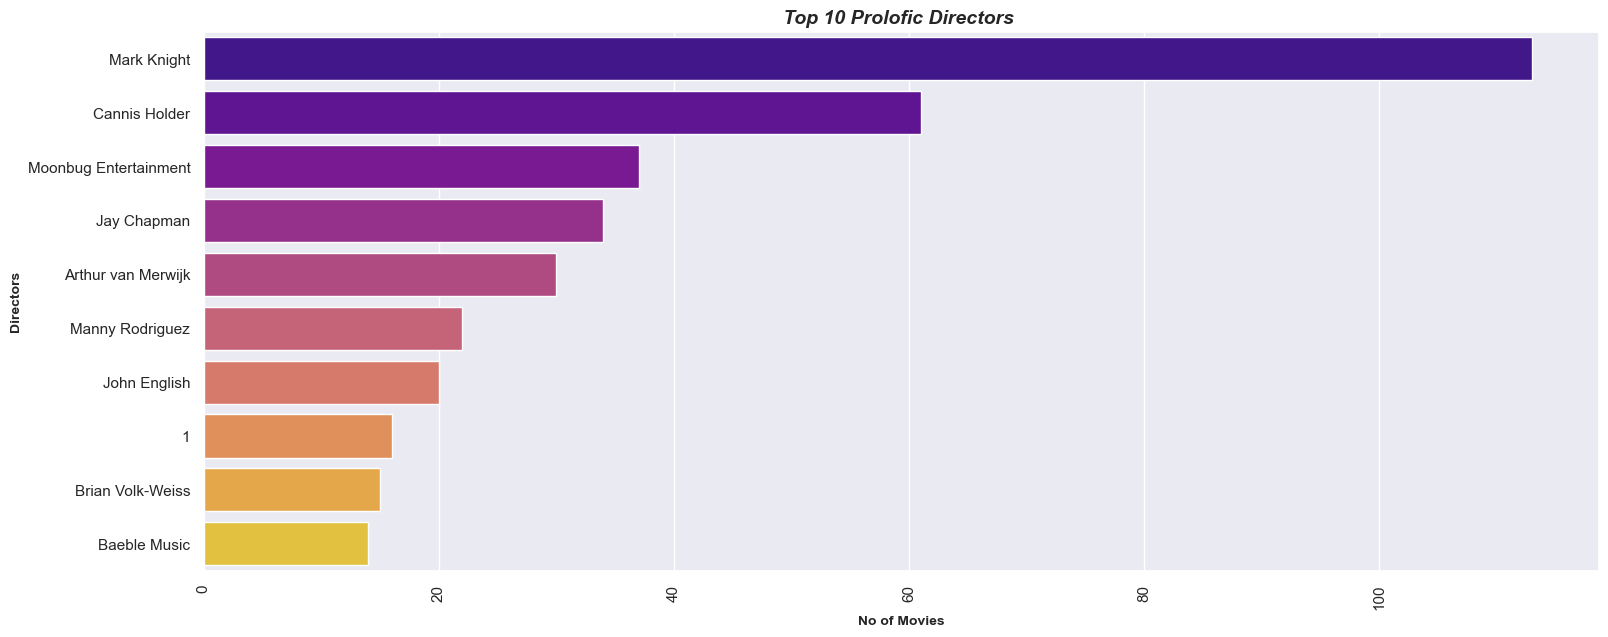

In [129]:
plt.figure(figsize=(18,7))
sns.barplot(
    x=top_directors.values ,
    y=top_directors.index ,
  
    palette='plasma'
)
plt.title(
    "Top 10 Prolofic Directors ",
    fontsize=14,
    fontweight='bold',
    fontstyle='italic',
)
plt.xlabel('No of Movies',fontsize=10,fontweight='bold')
plt.ylabel('Directors',fontsize=10,fontweight='bold')
plt.xticks(rotation=90)
plt.show()

In [130]:
filtered_cast=df[df.cast!='Unavailable']
top_cast=filtered_cast.cast.value_counts()[:10]
top_cast

cast
Maggie Binkley                      56
1                                   34
Anne-Marie Newland                  24
Cassandra Peterson                  21
Grace Tamayo, Erin Webbs            17
Gene Autry, Champion, Gail Davis    12
Stevin John                         11
LB, Aaron Michael                    9
Gallagher                            9
Eddie Izzard                         9
Name: count, dtype: int64

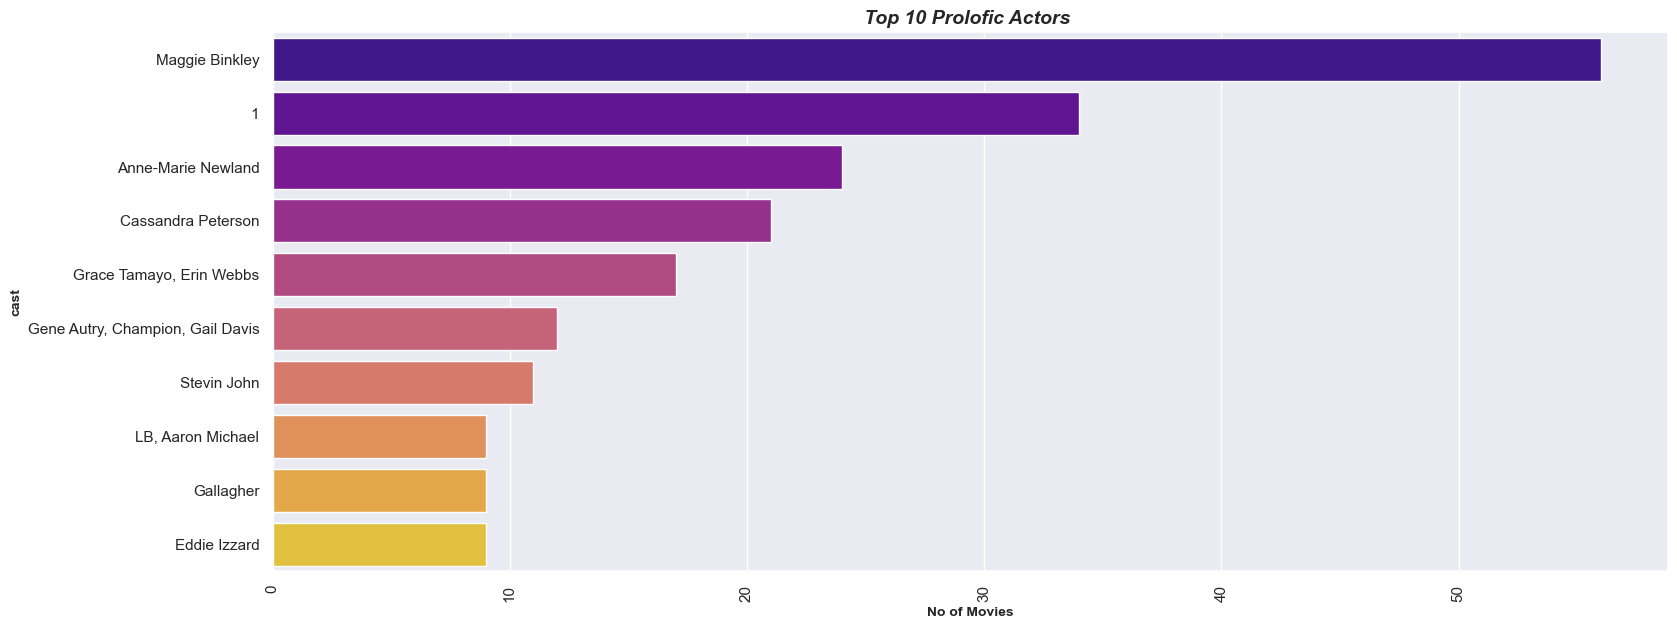

In [131]:
plt.figure(figsize=(18,7))
sns.barplot(
    x=top_cast.values ,
    y=top_cast.index ,
  
    palette='plasma'
)
plt.title(
    "Top 10 Prolofic Actors ",
    fontsize=14,
    fontweight='bold',
    fontstyle='italic',
)
plt.xlabel('No of Movies',fontsize=10,fontweight='bold')
plt.ylabel('cast',fontsize=10,fontweight='bold')
plt.xticks(rotation=90)
plt.show()

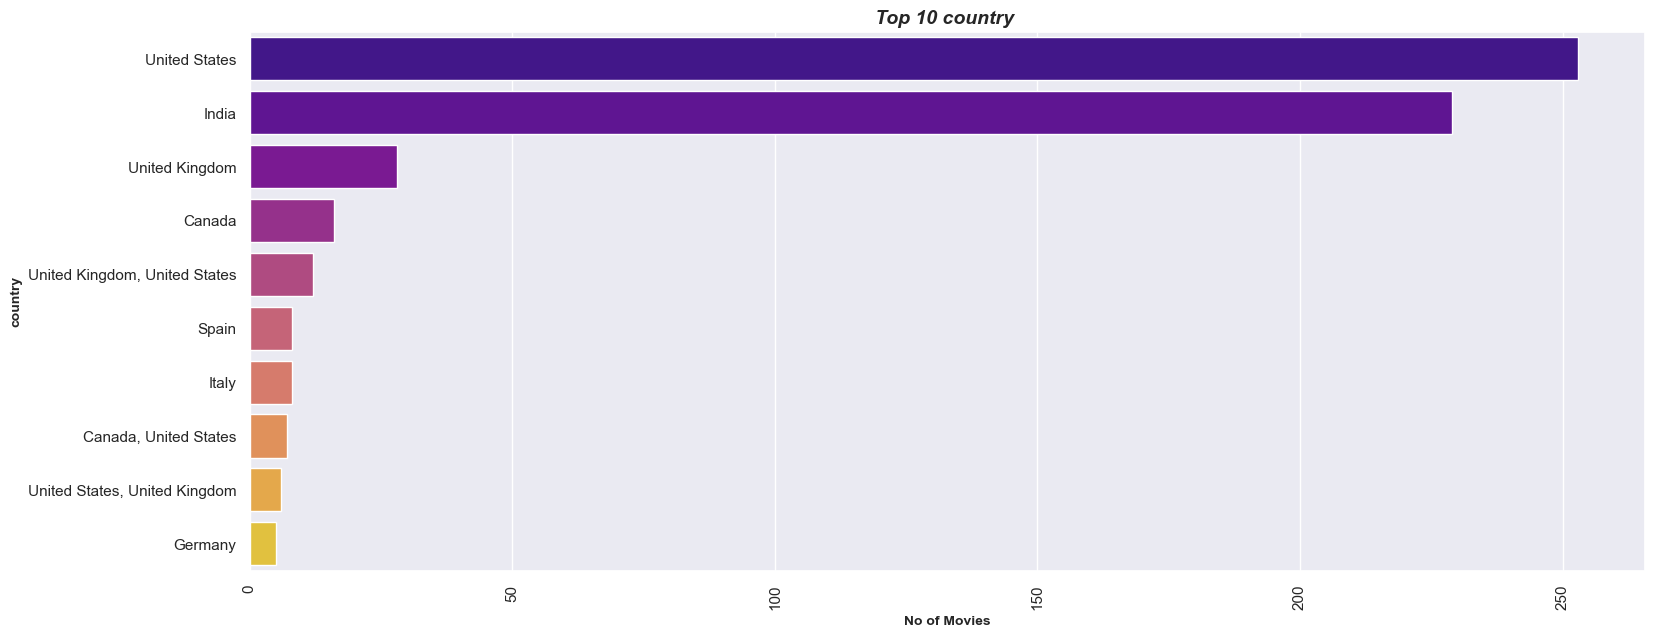

In [132]:
filtered_country=df[df.country!='Unavailable']
top_country=filtered_country.country.value_counts()[:10]

plt.figure(figsize=(18,7))
sns.barplot(
    x=top_country.values ,
    y=top_country.index ,
  
    palette='plasma'
)
plt.title(
    "Top 10 country ",
    fontsize=14,
    fontweight='bold',
    fontstyle='italic',
)
plt.xlabel('No of Movies',fontsize=10,fontweight='bold')
plt.ylabel('country',fontsize=10,fontweight='bold')
plt.xticks(rotation=90)
plt.show()

In [133]:
df.type.value_counts()

type
Movie      7814
TV Show    1854
Name: count, dtype: int64

<Axes: xlabel='type'>

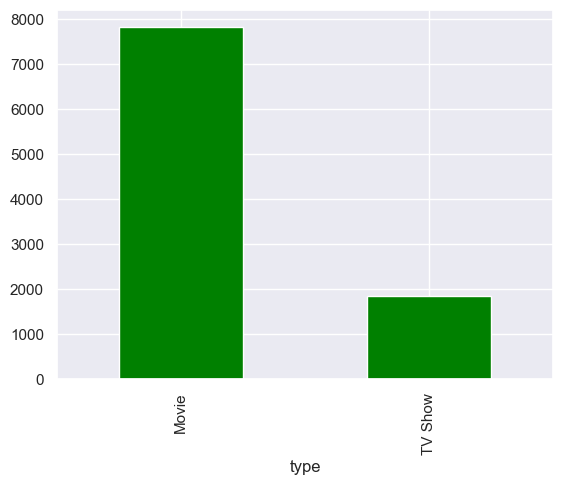

In [134]:
df.type.value_counts().plot(kind='bar',color='green')

<Axes: xlabel='type', ylabel='count'>

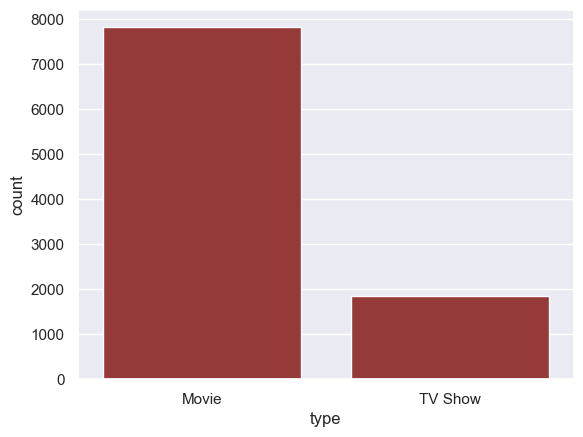

In [135]:
sns.countplot(x='type',data=df,color='brown')

In [136]:
d1=df.type.value_counts().reset_index()
d1

,type,count
0,Movie,7814
1,TV Show,1854


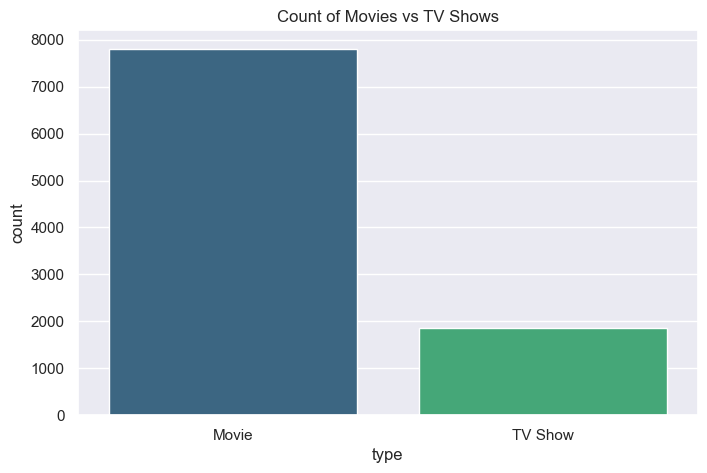

In [137]:
plt.figure(figsize=(8,5))

sns.countplot(x='type',data=df,palette='viridis')
plt.title('Count of Movies vs TV Shows')
plt.show()

<Axes: ylabel='count'>

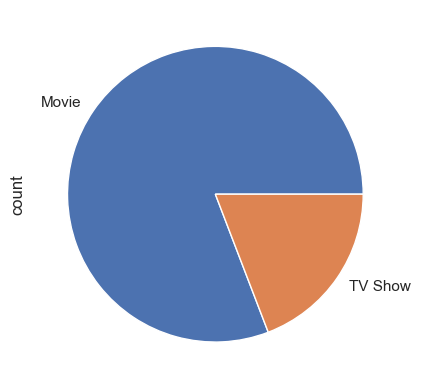

In [138]:
df.type.value_counts().plot(kind='pie',color='green')

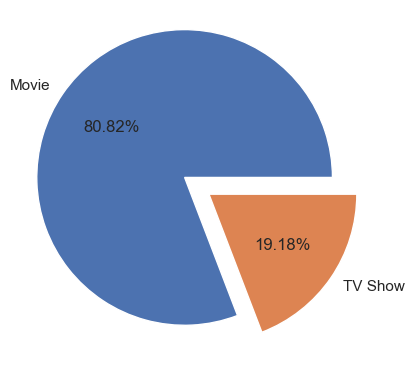

In [139]:
plt.pie(df.type.value_counts(),labels=df.type.value_counts().index,autopct='%1.2f%%',explode=[0.2,0])
plt.show()

In [140]:
df.rating.unique()

array(['13+', 'ALL', '18+', 'R', 'TV-Y', 'TV-Y7', 'NR', '16+', 'TV-PG',
       '7+', 'TV-14', 'TV-NR', 'TV-G', 'PG-13', 'TV-MA', 'G', 'PG',
       'NC-17', 'UNRATED', '16', 'AGES_16_', 'AGES_18_', 'ALL_AGES',
       'NOT_RATE'], dtype=object)

<Axes: xlabel='rating', ylabel='count'>

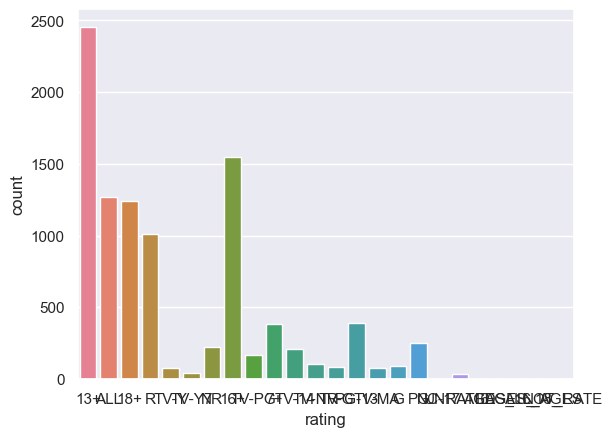

In [141]:
sns.countplot(x='rating',data=df,palette='husl')

<Axes: xlabel='rating', ylabel='count'>

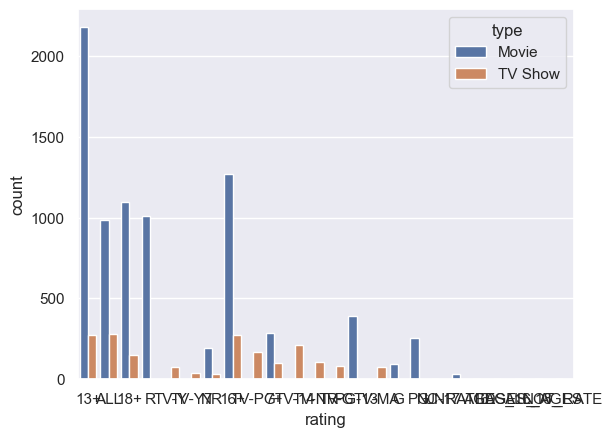

In [142]:
sns.countplot(x='rating',data=df,hue='type')

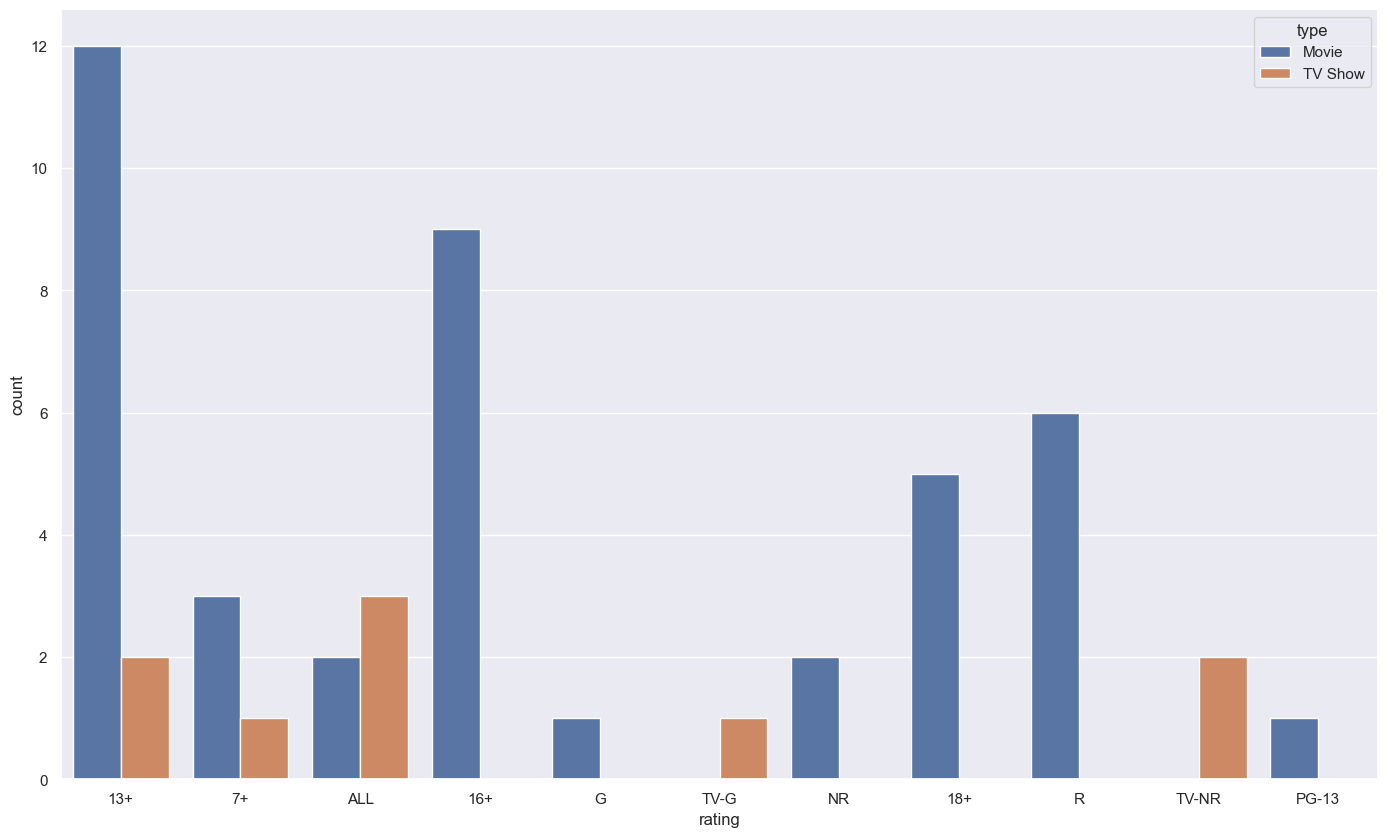

In [143]:
plt.figure(figsize=(17,10))
sns.countplot(x='rating',data=df.sample(50),hue='type')
plt.show()

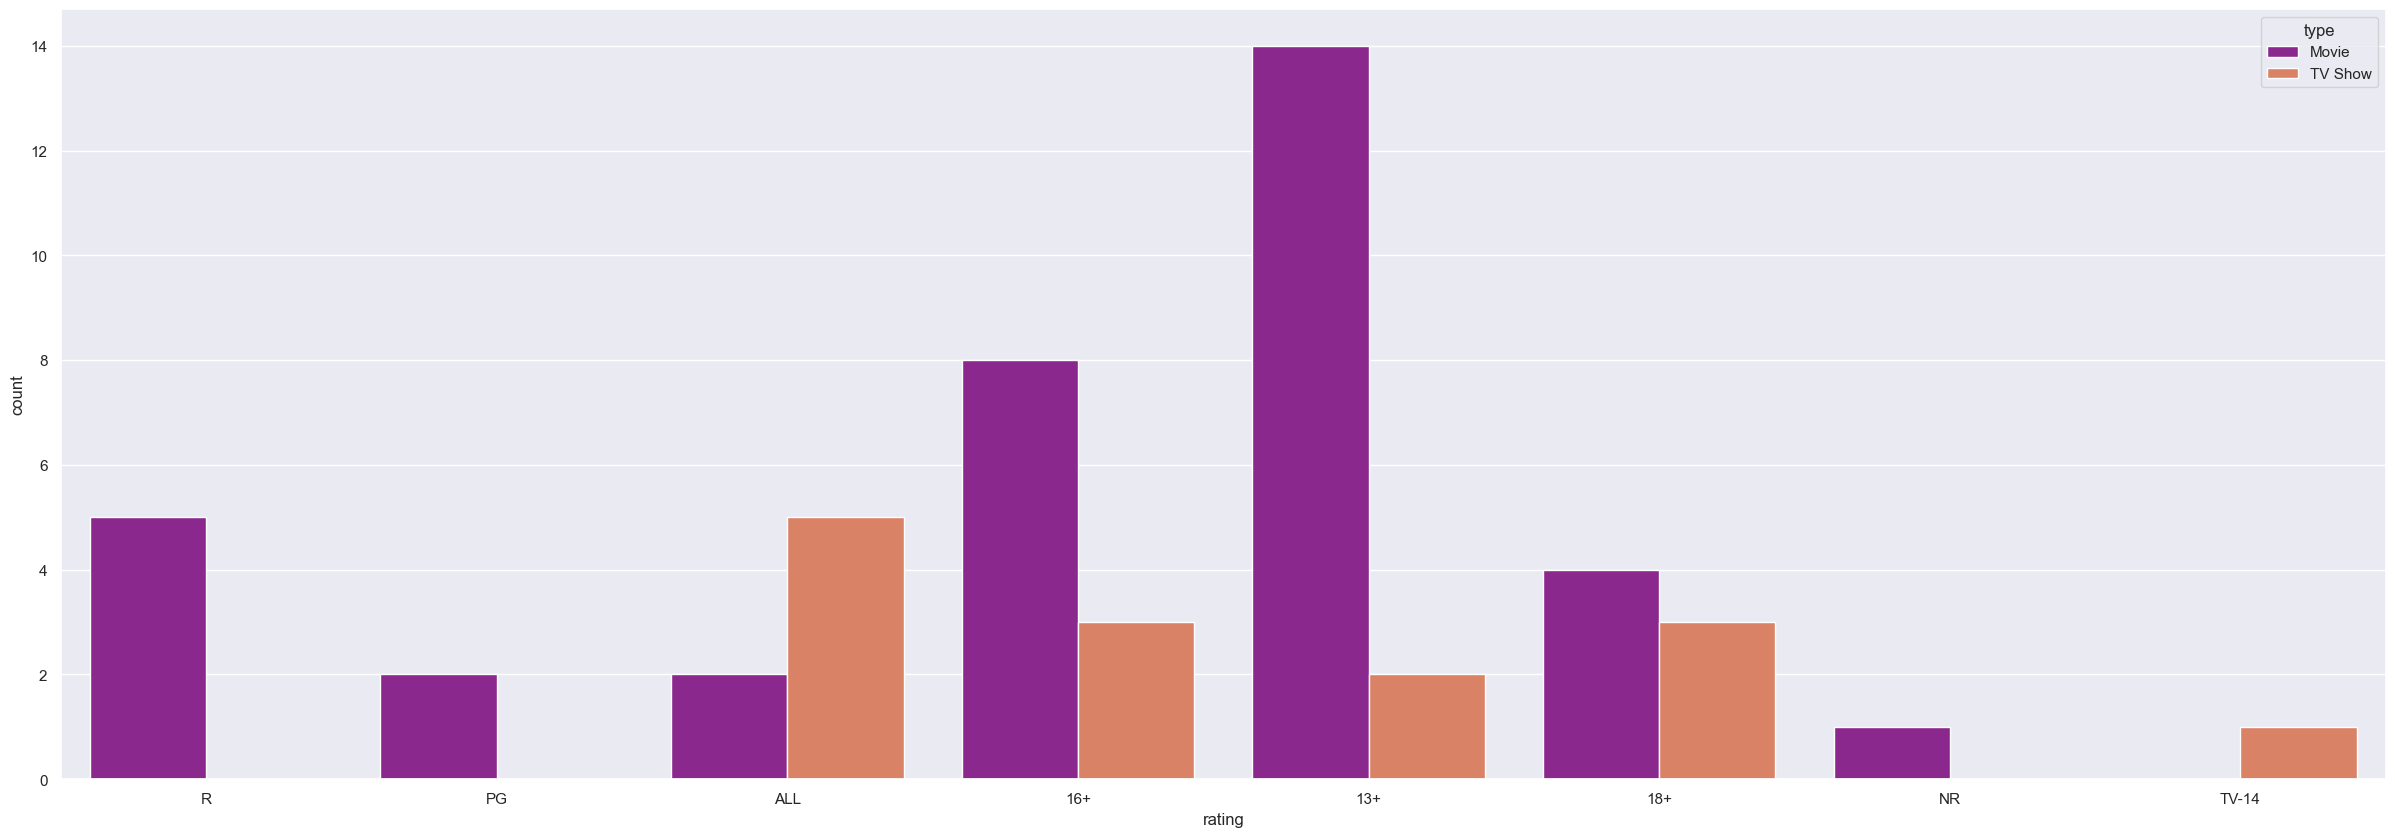

In [144]:
plt.figure(figsize=(30,10))
sns.countplot(x='rating',data=df.sample(50),hue='type',palette='plasma')
plt.show()

In [145]:
#Calculating the no of title per country
filtered_country=df[df.country!='Unavailable']
country_counts=filtered_country.country.value_counts()
country_counts

country
United States                                               253
India                                                       229
United Kingdom                                               28
Canada                                                       16
United Kingdom, United States                                12
                                                           ... 
United States, Mexico                                         1
United States, Germany, Japan, United Kingdom, Hong Kong      1
Italy, Canada                                                 1
France, Belgium                                               1
Italy, Spain                                                  1
Name: count, Length: 86, dtype: int64

In [146]:
# getting top 3 countries
top_countries=country_counts.nlargest(3).index
top_countries

Index(['United States', 'India', 'United Kingdom'], dtype='object', name='country')

In [147]:
#filtering the DataFrame to include only 3 countries
df_top_countries=filtered_country[filtered_country.country.isin(top_countries)]
df_top_countries

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,day,month,year,month_name,weekday
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International",30,3,2021,March,Tuesday
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense",30,3,2021,March,Tuesday
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary,30,3,2021,March,Tuesday
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,13+,45 min,"Drama, Fantasy",30,3,2021,March,Tuesday
5,Movie,Living With Dinosaurs,Paul Weiland,"Gregory Chisholm, Juliet Stevenson, Brian Hens...",United Kingdom,2021-03-30,1989,13+,52 min,"Fantasy, Kids",30,3,2021,March,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9604,Movie,Bride Wars,Gary Winick,"Kate Hudson, Anne Hathaway, Kristen Johnston, ...",United States,2021-10-08,2009,PG,89 min,Comedy,8,10,2021,October,Friday
9614,Movie,What Happens in Vegas,Tom Vaughan,"Cameron Diaz, Ashton Kutcher, Rob Corddry, ...",United States,2021-10-08,2008,PG-13,99 min,Comedy,8,10,2021,October,Friday
9641,Movie,Marley & Me,David Frankel,"Owen Wilson, Jennifer Aniston",United States,2021-10-10,2008,PG,116 min,"Comedy, Drama, Kids",10,10,2021,October,Sunday
9643,Movie,Love & Other Drugs,Edward Zwick,"K K, Jake Gyllenhaal, Anne Hathaway, Oliver Pl...",United States,2021-10-10,2010,R,112 min,"Comedy, Drama",10,10,2021,October,Sunday


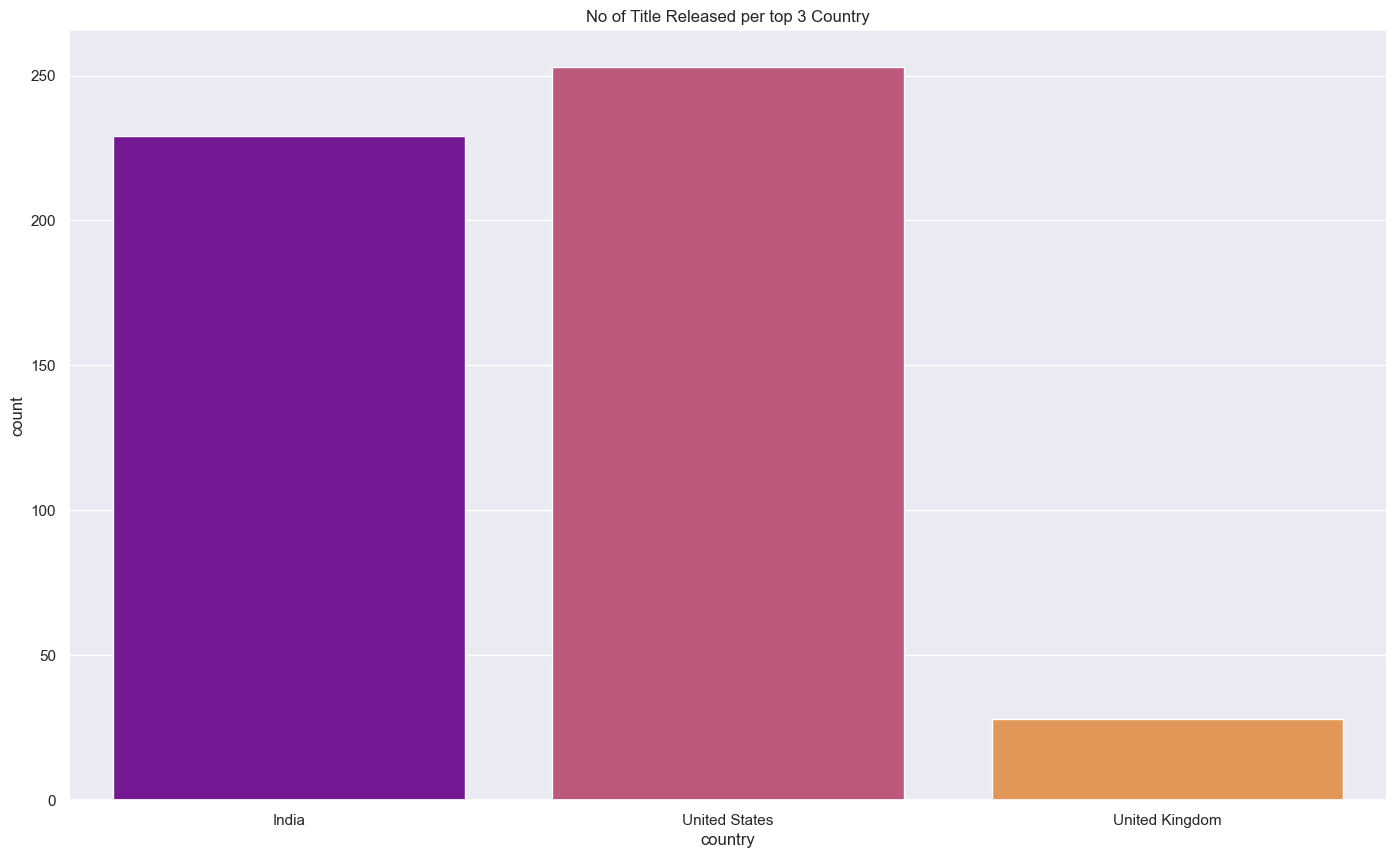

In [148]:
# plotting
plt.figure(figsize=(17,10))
sns.countplot(x='country',data=df_top_countries,palette='plasma')
plt.title('No of Title Released per top 3 Country')
plt.show()

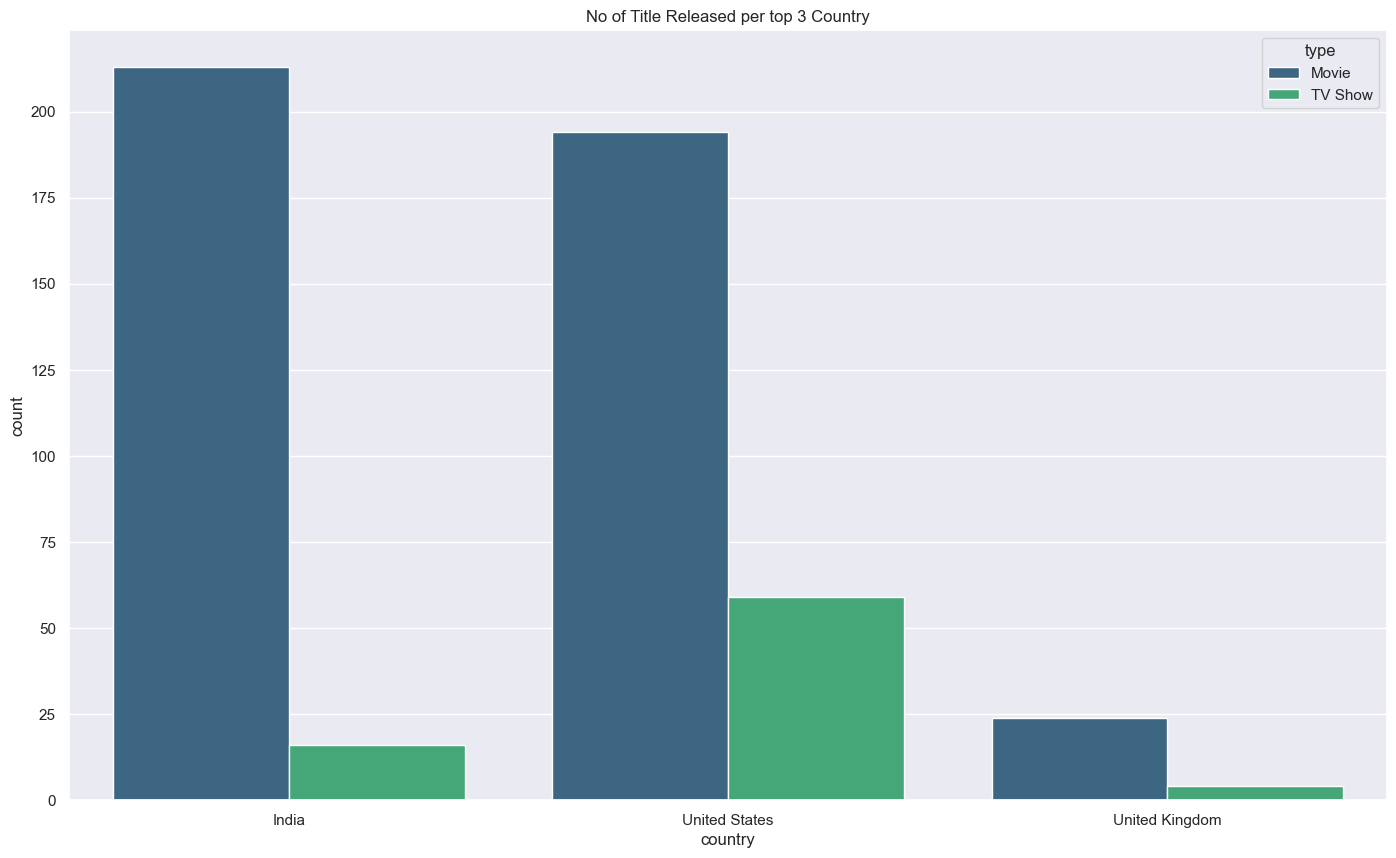

In [149]:
# plotting
plt.figure(figsize=(17,10))
sns.countplot(x='country',data=df_top_countries,palette='viridis',hue='type')
plt.title('No of Title Released per top 3 Country')
plt.show()

In [150]:
df.release_year.unique()

array([2014, 2018, 2017, 1989, 2016, 1994, 2020, 2019, 2008, 2001, 1941,
       1991, 2005, 2015, 2011, 2013, 1949, 2007, 2002, 1955, 1959, 1983,
       2009, 2012, 2010, 1986, 1988, 1920, 1936, 1992, 2021, 1993, 2006,
       1948, 1946, 1944, 1935, 1985, 1937, 1970, 1945, 1939, 1996, 1997,
       1974, 1938, 1978, 2004, 1943, 1975, 1960, 1934, 1940, 1961, 2003,
       2000, 1967, 1995, 1951, 1932, 1999, 1963, 1969, 1952, 1947, 1929,
       1990, 1925, 1968, 1987, 1942, 1979, 1980, 1981, 1976, 1966, 1973,
       1956, 1972, 1950, 1953, 1982, 1977, 1933, 1958, 1984, 1998, 1924,
       1922, 1926, 1954, 1930, 1971, 1965, 1931, 1923, 1962, 1964, 1957,
       1927])

In [151]:
df.release_year.value_counts()

release_year
2021    1442
2020     962
2019     929
2018     623
2017     562
        ... 
1926       2
1922       2
1924       1
1923       1
1927       1
Name: count, Length: 100, dtype: int64

In [152]:
year_counts=df.release_year.value_counts()
top_years=year_counts.nlargest(10).index
top_years

Index([2021, 2020, 2019, 2018, 2017, 2016, 2014, 2015, 2013, 2012], dtype='int64', name='release_year')

In [153]:
df_top_years=df[df.release_year.isin(top_years)]
df_top_years

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,day,month,year,month_name,weekday
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama",30,3,2021,March,Tuesday
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International",30,3,2021,March,Tuesday
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense",30,3,2021,March,Tuesday
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary,30,3,2021,March,Tuesday
6,Movie,Hired Gun,Fran Strine,"Alice Cooper, Liberty DeVitto, Ray Parker Jr.,...",United States,2021-03-30,2017,13+,98 min,"Documentary, Special Interest",30,3,2021,March,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9657,Movie,A Place at the Table,"Kristi Jacobson, Lori Silverbush","Jeff Bridges, Tom Colicchio",Unavailable,2021-10-10,2013,PG,84 min,"Documentary, Special Interest",10,10,2021,October,Sunday
9660,Movie,The Man in the Hat,"John-Paul Davidson, Stephen Warbeck","Ciaran Hinds, Stephen Dillane, Maïwenn",Unavailable,2021-10-10,2021,13+,96 min,Comedy,10,10,2021,October,Sunday
9662,Movie,River,Emily Skye,"Mary Cameron Rogers, Alexandra Rose, Rob Marsh...",Unavailable,2021-10-10,2021,16+,93 min,"Drama, Science Fiction, Suspense",10,10,2021,October,Sunday
9664,TV Show,Planet Patrol,Unavailable,"DICK VOSBURGH, RONNIE STEVENS, LIBBY MORRIS, M...",Unavailable,2021-10-10,2018,13+,4 Seasons,TV Shows,10,10,2021,October,Sunday


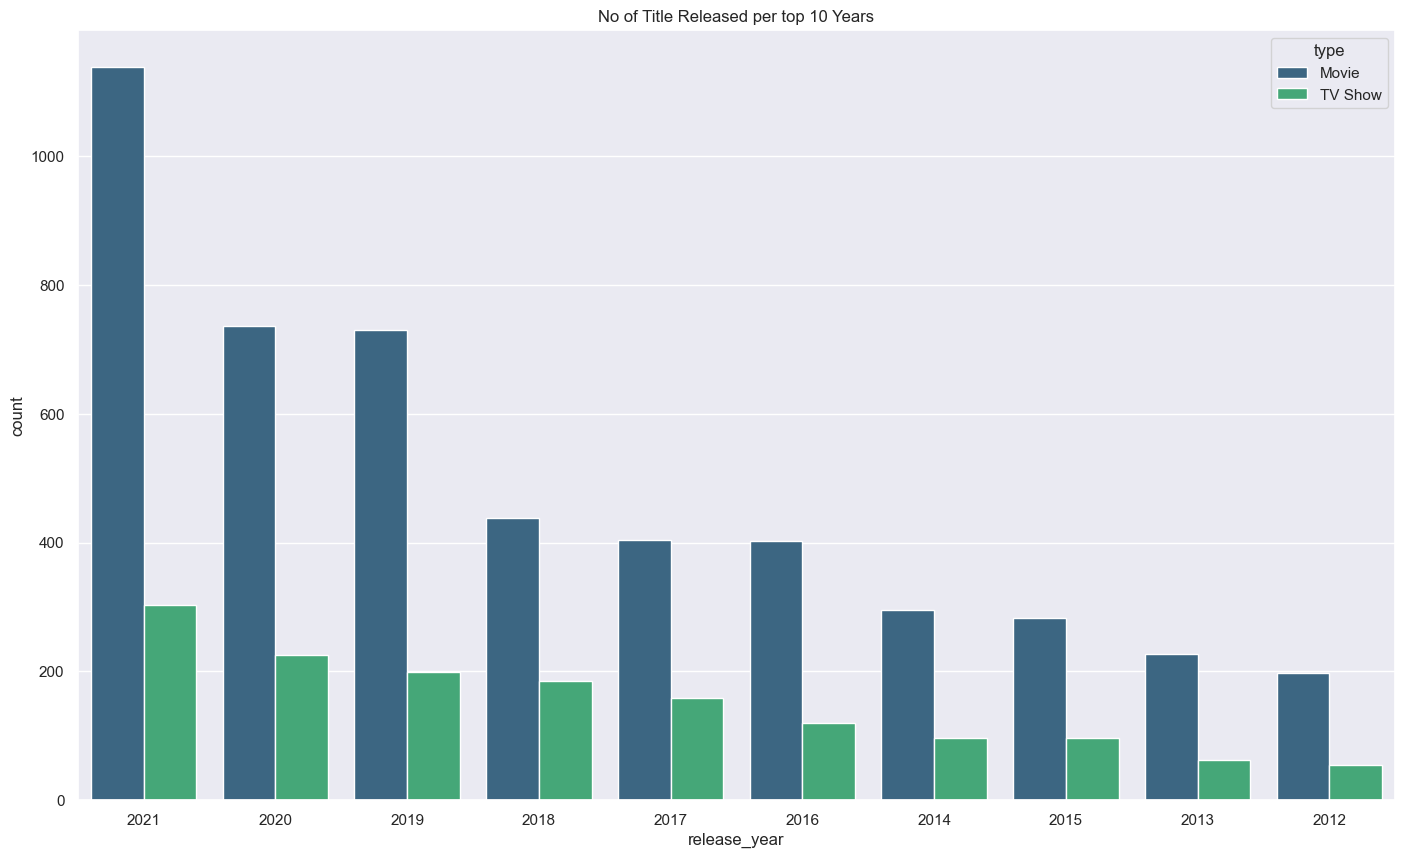

In [154]:
# plotting
plt.figure(figsize=(17,10))
sns.countplot(x='release_year',data=df_top_years,palette='viridis',hue='type',order=top_years)
plt.title('No of Title Released per top 10 Years')
plt.show()

In [155]:
df['Genres']=df['genre'].apply(lambda x:x.split(', '))
df

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,day,month,year,month_name,weekday,Genres
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama",30,3,2021,March,Tuesday,"[Comedy, Drama]"
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International",30,3,2021,March,Tuesday,"[Drama, International]"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense",30,3,2021,March,Tuesday,"[Action, Drama, Suspense]"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary,30,3,2021,March,Tuesday,[Documentary]
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,13+,45 min,"Drama, Fantasy",30,3,2021,March,Tuesday,"[Drama, Fantasy]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9663,Movie,Pride Of The Bowery,Joseph H. Lewis,"Leo Gorcey, Bobby Jordan",Unavailable,2021-10-10,1940,7+,60 min,Comedy,10,10,2021,October,Sunday,[Comedy]
9664,TV Show,Planet Patrol,Unavailable,"DICK VOSBURGH, RONNIE STEVENS, LIBBY MORRIS, M...",Unavailable,2021-10-10,2018,13+,4 Seasons,TV Shows,10,10,2021,October,Sunday,[TV Shows]
9665,Movie,Outpost,Steve Barker,"Ray Stevenson, Julian Wadham, Richard Brake, M...",Unavailable,2021-10-10,2008,R,90 min,Action,10,10,2021,October,Sunday,[Action]
9666,TV Show,Maradona: Blessed Dream,Unavailable,"Esteban Recagno, Ezequiel Stremiz, Luciano Vit...",Unavailable,2021-10-10,2021,TV-MA,1 Season,"Drama, Sports",10,10,2021,October,Sunday,"[Drama, Sports]"


In [156]:
genres_exploded=df.explode('Genres')
genres_exploded

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,day,month,year,month_name,weekday,Genres
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama",30,3,2021,March,Tuesday,Comedy
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama",30,3,2021,March,Tuesday,Drama
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International",30,3,2021,March,Tuesday,Drama
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International",30,3,2021,March,Tuesday,International
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense",30,3,2021,March,Tuesday,Action
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9666,TV Show,Maradona: Blessed Dream,Unavailable,"Esteban Recagno, Ezequiel Stremiz, Luciano Vit...",Unavailable,2021-10-10,2021,TV-MA,1 Season,"Drama, Sports",10,10,2021,October,Sunday,Drama
9666,TV Show,Maradona: Blessed Dream,Unavailable,"Esteban Recagno, Ezequiel Stremiz, Luciano Vit...",Unavailable,2021-10-10,2021,TV-MA,1 Season,"Drama, Sports",10,10,2021,October,Sunday,Sports
9667,Movie,Harry Brown,Daniel Barber,"Michael Caine, Emily Mortimer, Joseph Gilgun, ...",Unavailable,2021-10-10,2010,R,103 min,"Action, Drama, Suspense",10,10,2021,October,Sunday,Action
9667,Movie,Harry Brown,Daniel Barber,"Michael Caine, Emily Mortimer, Joseph Gilgun, ...",Unavailable,2021-10-10,2010,R,103 min,"Action, Drama, Suspense",10,10,2021,October,Sunday,Drama


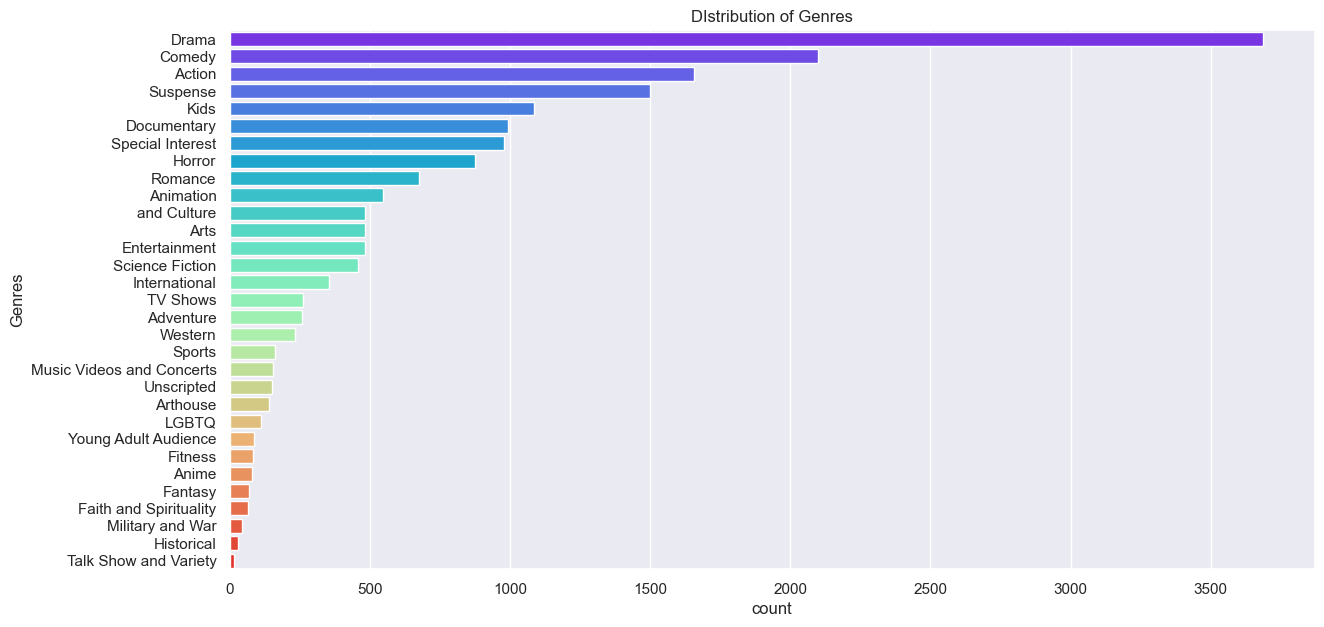

In [157]:
x=genres_exploded.Genres.value_counts().index
plt.figure(figsize=(14,7))
sns.countplot(data=genres_exploded,y='Genres',order=x,
             palette='rainbow')
plt.title('DIstribution of Genres')
plt.show()

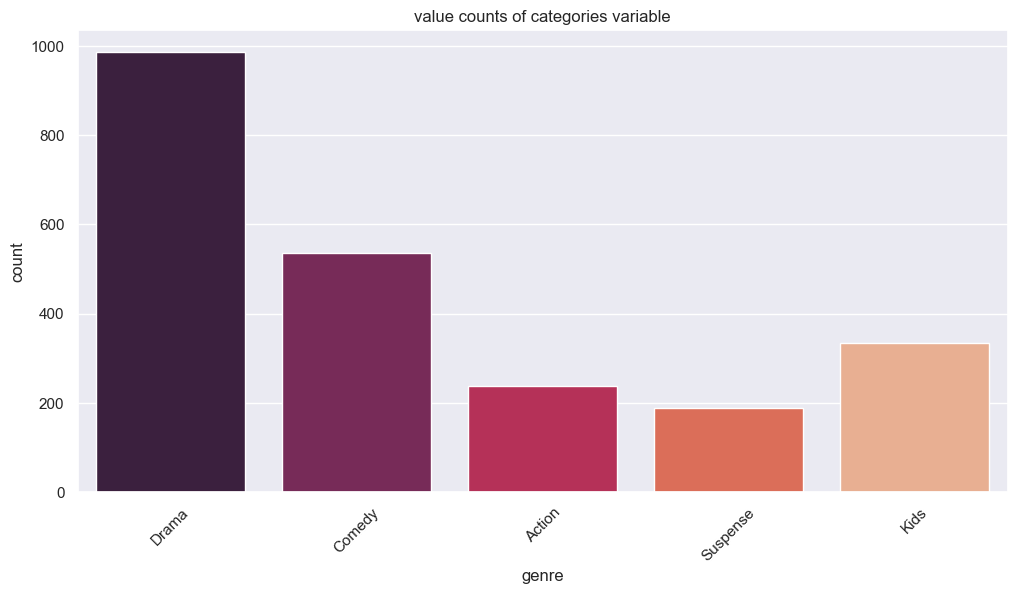

In [158]:
df['Genres'] = df['genre'].apply(lambda x: x.split(', '))
genres_exploded = df.explode('Genres')
plt.figure(figsize=(12,6))
plt.title('value counts of categories variable')
sns.set(style='darkgrid')
sns.countplot(x='genre',data=genres_exploded,palette='rocket',order=genres_exploded.Genres.value_counts().iloc[:5].index)
plt.xticks(rotation=45)
plt.show()

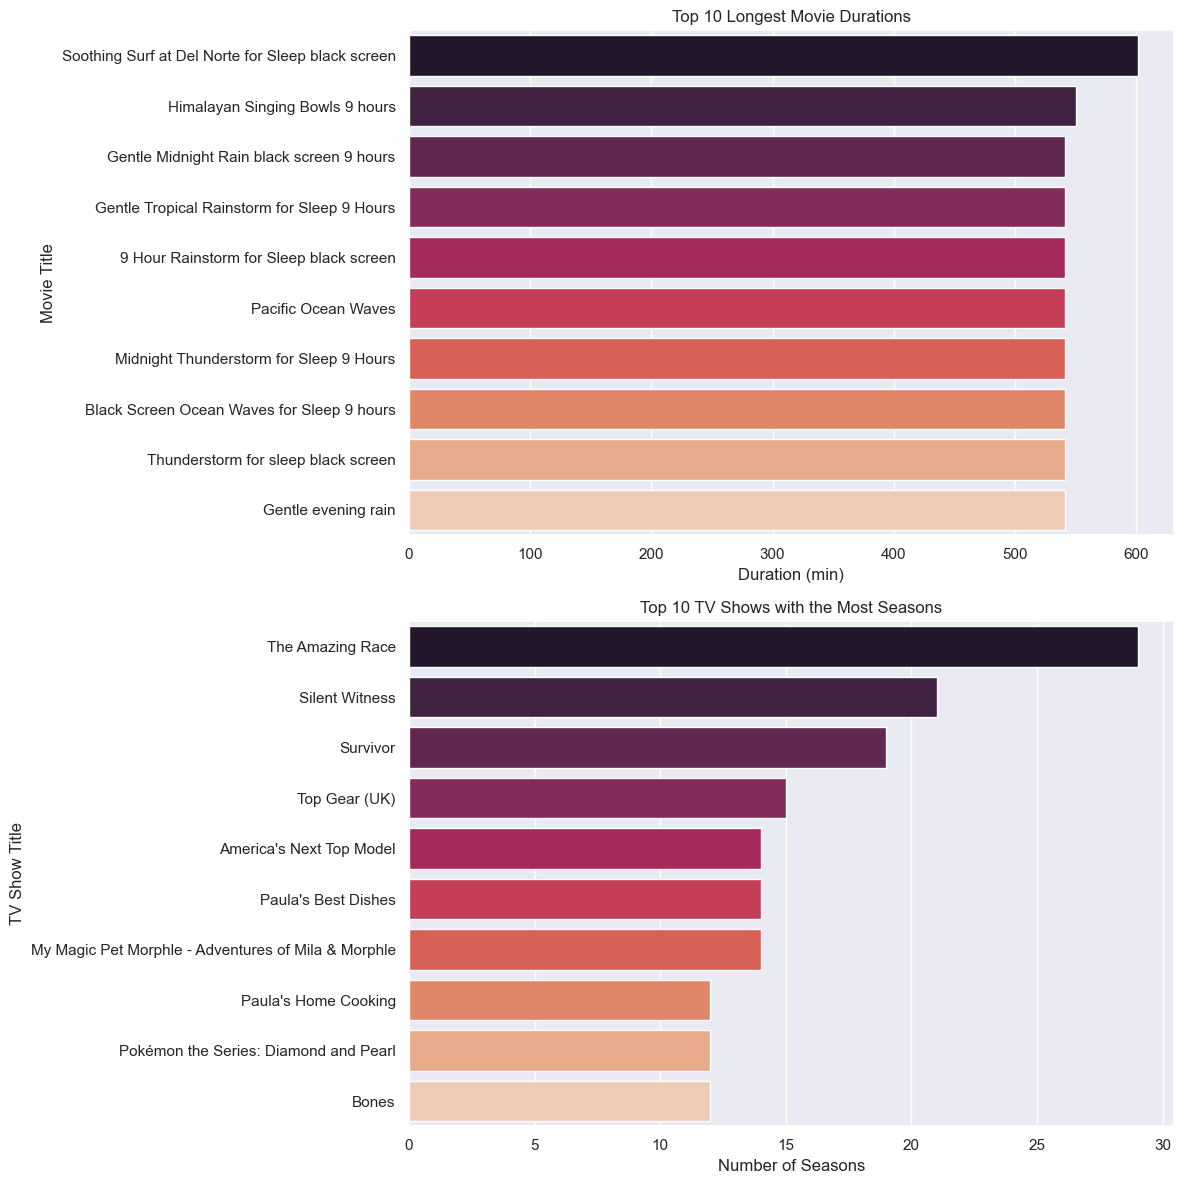

In [160]:
# Filter data for movies and TV shows separately
df_movies = df[df.type == 'Movie'].copy()
df_tv_shows = df[df.type == 'TV Show'].copy()

# Extract numeric duration for movies
df_movies['duration_num'] = df_movies['duration'].str.extract('(\d+)', expand=False).astype(float)

# Extract numeric duration for TV shows
df_tv_shows['duration_num'] = df_tv_shows['duration'].str.extract('(\d+)', expand=False).astype(float)

# Plotting
plt.figure(figsize=(12, 12))

# Subplot 1: Top 10 Longest Movie Duration
plt.subplot(2, 1, 1)
sns.barplot(data=df_movies.sort_values(by='duration_num',
                                       ascending=False).head(10), y='title', x='duration_num',
                                       orient='horizontal',palette='rocket')
plt.title('Top 10 Longest Movie Durations')
plt.xlabel('Duration (min)')
plt.ylabel('Movie Title')

# Subplot 2: Top 10 TV Shows with the Most Seasons
plt.subplot(2, 1, 2)
sns.barplot(data=df_tv_shows.sort_values(by='duration_num', ascending=False).head(10),
            y='title', x='duration_num', orient='horizontal',palette='rocket')
plt.title('Top 10 TV Shows with the Most Seasons')
plt.xlabel('Number of Seasons')
plt.ylabel('TV Show Title')
plt.tight_layout()
plt.show()